In [1]:
from astropy.io import fits
import os
import xupy as xp
import numpy as np
import matplotlib.pyplot as plt

from numpy.ma import masked_array

from ekarus.e2e.utils.image_utils import reshape_on_mask, get_circular_mask, get_photocenter
from ekarus.e2e.utils.deformable_mirror_utilities import simulate_influence_functions

from arte.math.toccd import toccd

from scipy.interpolate import Rbf


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 4060 Laptop GPU`
       Memory = 7805.56 MB | Compute Capability = 8.9
       Using CuPy 13.5.1 for acceleration.


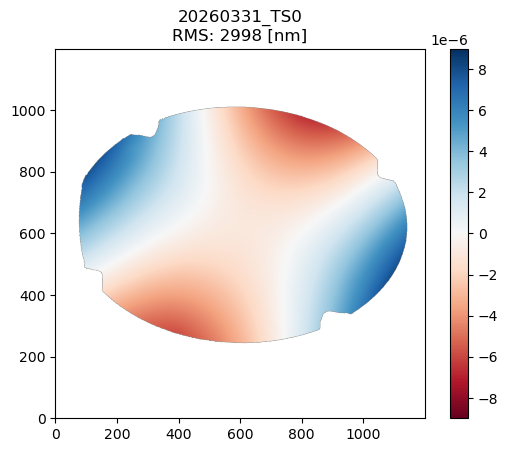

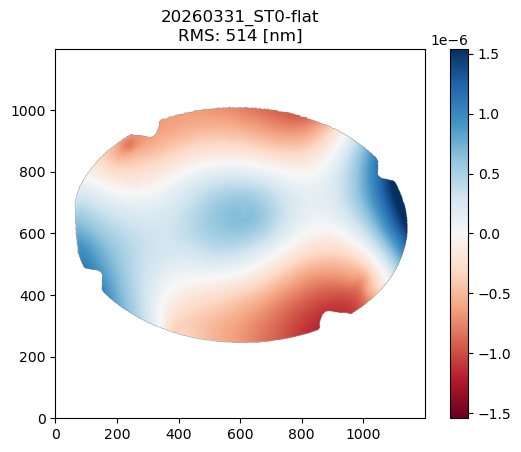

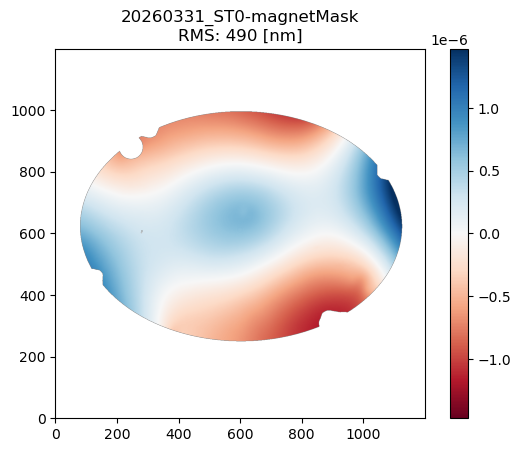

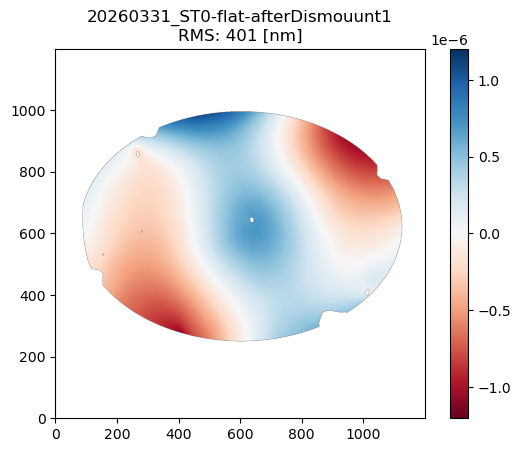

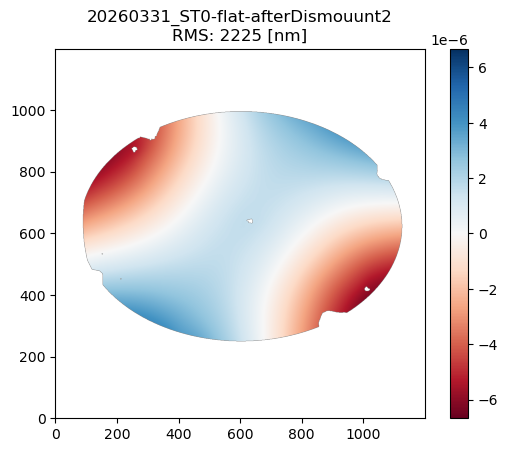

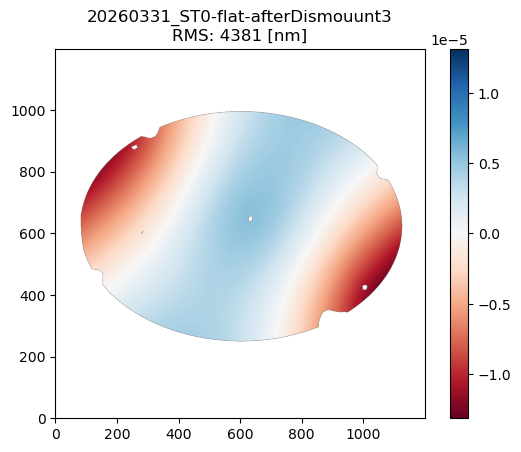

In [2]:
os.chdir('/home/matte/Downloads')

filelist = ['20260331_TS0','20260331_ST0-flat','20260331_ST0-magnetMask',
            '20260331_ST0-flat-afterDismouunt1','20260331_ST0-flat-afterDismouunt2',
            '20260331_ST0-flat-afterDismouunt3']

for file in filelist:
    frame = fits.getdata(file+'.fits')
    mask = abs(frame) > 0
    frame -= xp.mean(frame[mask])
    rms = xp.std(frame[mask])
    plt.figure()
    plt.imshow(frame,origin='lower',cmap='RdBu',vmin = -3*rms, vmax = 3*rms)
    plt.title(f'{file}\nRMS: {rms*1e+9:1.0f} [nm]')
    plt.colorbar()

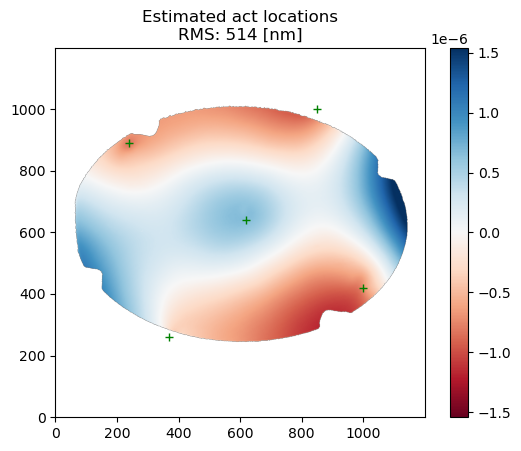

In [3]:
frame = xp.array(fits.getdata('20260331_ST0-flat.fits'))#'20260331_TS0.fits')#'20260331_ST0-flat-afterDismouunt1.fits') #
mask = xp.array(abs(frame) > 0,dtype=bool)
frame -= xp.mean(frame[mask])
rms = xp.std(frame[mask])

img = reshape_on_mask(frame[mask],(1-mask).astype(bool))

act_coords = xp.array([[890,240],[640,620],[640-380,620-250],[420,1000],[620+380,600+250]]).T

plt.figure()
plt.plot(xp.asnumpy(act_coords[1]),xp.asnumpy(act_coords[0]),'+',c='green')
plt.imshow(xp.asnumpy(frame),origin='lower',cmap='RdBu',vmin = -3*rms, vmax = 3*rms)
plt.title(f'Estimated act locations\nRMS: {rms*1e+9:1.0f} [nm]')
plt.colorbar()

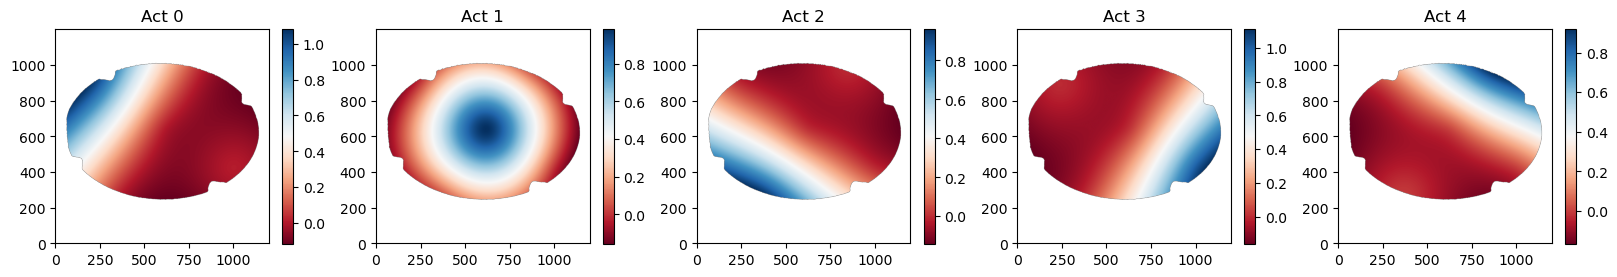

In [4]:
local_mask = xp.array((1-mask).astype(bool))
IF = simulate_influence_functions(act_coords=act_coords,local_mask=local_mask)
R = xp.linalg.pinv(IF)

plt.figure(figsize=(20,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(masked_array(xp.asnumpy(reshape_on_mask(IF[:,i],local_mask)),mask=xp.asnumpy(local_mask)),origin='lower',cmap='RdBu')
    plt.colorbar(shrink=0.7)
    plt.title(f'Act {i}')

Text(0.5, 1.0, 'Residual\nRMS: 507 [nm]')

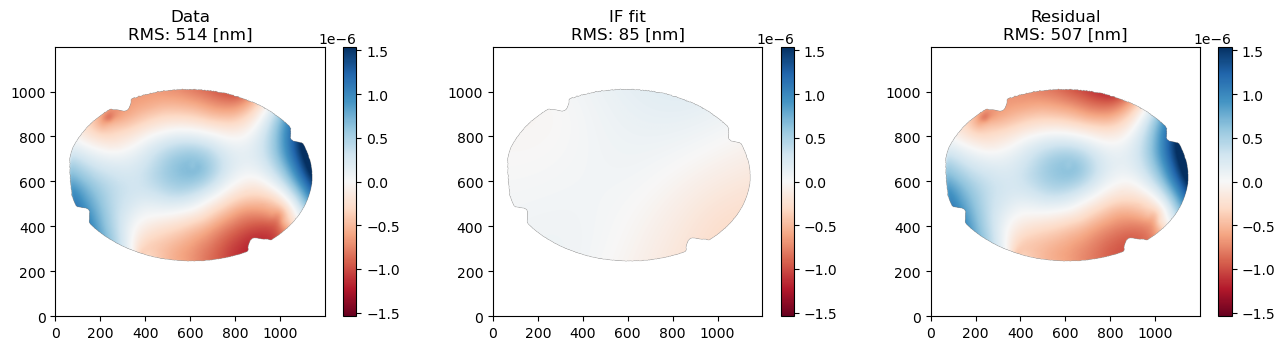

In [5]:
coeffs = R @ img[~local_mask]
fit_img = reshape_on_mask(IF @ coeffs,local_mask)
res_img = img - fit_img

rms = xp.std(img[~local_mask])

plt.figure(figsize=(16, 3.5))
plt.subplot(1, 3, 1)
plt.imshow(masked_array(xp.asnumpy(img), mask=xp.asnumpy(local_mask)), origin='lower', cmap='RdBu',vmin = -3*rms, vmax = 3*rms)
plt.colorbar()
plt.title(f'Data\nRMS: {xp.std(img[~local_mask])*1e+9:1.0f} [nm]')
plt.subplot(1, 3, 2)
plt.imshow(masked_array(xp.asnumpy(fit_img), mask=xp.asnumpy(local_mask)), origin='lower', cmap='RdBu',vmin = -3*rms, vmax = 3*rms)
plt.colorbar()
plt.title(f'IF fit\nRMS: {xp.std(fit_img[~local_mask])*1e+9:1.0f} [nm]')
plt.subplot(1, 3, 3)
plt.imshow(masked_array(xp.asnumpy(res_img), mask=xp.asnumpy(local_mask)), origin='lower', cmap='RdBu',vmin = -3*rms, vmax = 3*rms)
plt.colorbar()
plt.title(f'Residual\nRMS: {xp.std(res_img[~local_mask])*1e+9:1.0f} [nm]')

In [6]:
pix_scale = 100e-3/1100 # m/pix

def simulate_ibf(image, fwhm:float, IF, R, mask=None, iff_mask=None, amp:float=1e-8, pix_scale:float=pix_scale, rms=400e-9):

    if mask is None:
        mask = abs(image) > 0
        mask = (1-mask).astype(bool)

    if iff_mask is None:
        iff_mask = mask.copy()

    # Gaussian removal function
    sigma = fwhm/pix_scale/(xp.sqrt(xp.log(2**8)))

    X,Y = xp.mgrid[0:image.shape[0],0:image.shape[1]]
    X -= (xp.max(X)-xp.min(X))//2
    Y -= (xp.max(Y)-xp.min(Y))//2
    rf = 1/(2*xp.pi*sigma**2)*xp.exp(-(X**2+Y**2)/(2*sigma**2))
    rf *= amp

    if_coeffs = R @ image[~iff_mask]
    rec_img = reshape_on_mask(IF @ if_coeffs,iff_mask)
    img_fit = image - rec_img

    # Deconvolution
    img_ft = xp.fft.fft2(img_fit)
    rf_ft = xp.fft.fft2(rf)

    noise_power = amp  # adjust based on noise level
    denominator = xp.abs(rf_ft)**2 + noise_power
    deconv_ft = img_ft * xp.conj(rf_ft) / denominator
    deconv = xp.fft.ifft2(deconv_ft)
    removed = xp.real(xp.fft.fftshift(deconv))

    ibf_img = img_fit-removed
    if_coeffs = R @ ibf_img[~iff_mask]
    rec_ibf = reshape_on_mask(IF @ if_coeffs,iff_mask)
    ibf_fit = ibf_img - rec_ibf

    plt.figure(figsize=(16,9))
    plt.subplot(2,3,1)
    plt.imshow(masked_array(xp.asnumpy(image),mask=xp.asnumpy(mask)), origin='lower', cmap='RdBu', vmin=-3*rms, vmax=3*rms)
    plt.colorbar()
    plt.title(f'Image\nRMS={xp.std(image[~mask.astype(bool)])*1e+9:1.0f} [nm]')
    plt.subplot(2,3,2)
    plt.imshow(masked_array(xp.asnumpy(rec_img),mask=xp.asnumpy(mask)), origin='lower', cmap='RdBu', vmin=-3*rms, vmax=3*rms)
    plt.colorbar()
    plt.title(f'IF fit\nRMS={xp.std(rec_img[~mask.astype(bool)])*1e+9:1.0f} [nm]')
    plt.subplot(2,3,3)
    plt.imshow(masked_array(xp.asnumpy(img_fit),mask=xp.asnumpy(iff_mask)), origin='lower', cmap='RdBu', vmin=-3*rms, vmax=3*rms)
    plt.colorbar()
    plt.title(f'Image (IF removed)\nRMS={xp.std(img_fit[~mask.astype(bool)])*1e+9:1.0f} [nm]')
    plt.subplot(2,3,4)
    plt.imshow(masked_array(xp.asnumpy(removed),mask=xp.asnumpy(mask)), origin='lower', cmap='RdBu', vmin=-3*rms, vmax=3*rms)
    plt.colorbar()
    plt.title(f'IBF removed material\nRMS={xp.std(removed[~mask.astype(bool)])*1e+9:1.0f}  [nm]')
    plt.subplot(2,3,5)
    plt.imshow(masked_array(xp.asnumpy(ibf_img),mask=xp.asnumpy(mask)), origin='lower', cmap='RdBu', vmin=-3*rms, vmax=3*rms)
    plt.colorbar()
    plt.title(f'After IBF\nRMS={xp.std(ibf_img[~mask.astype(bool)])*1e+9:1.0f} [nm]')
    plt.subplot(2,3,6)
    plt.imshow(masked_array(xp.asnumpy(ibf_fit),mask=xp.asnumpy(mask)), origin='lower', cmap='RdBu', vmin=-3*rms, vmax=3*rms)
    plt.colorbar()
    plt.title(f'After IBF and IF fitting\nRMS={xp.std(ibf_fit[~mask.astype(bool)])*1e+9:1.0f} [nm]')
    return ibf_img

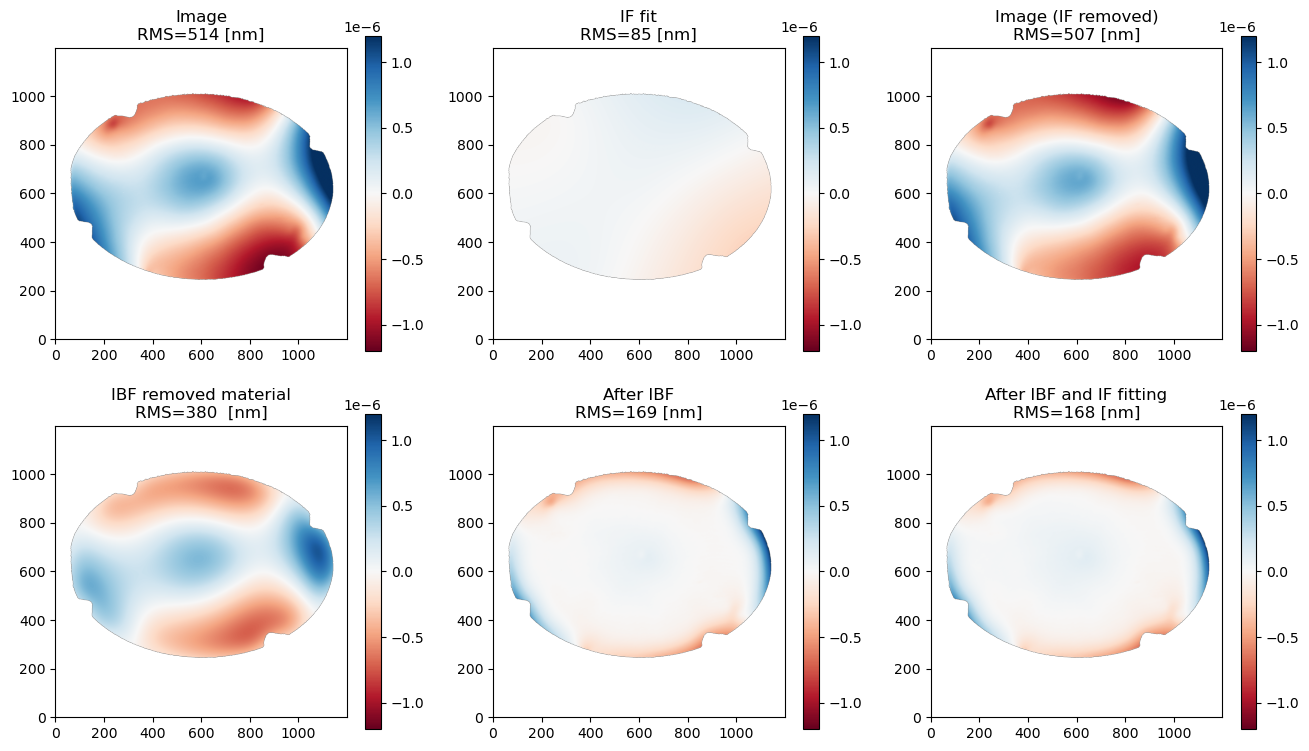

In [7]:
ibf_img = simulate_ibf(img, IF=IF, R=R, fwhm=10e-3, amp=1e-8)

Text(0.5, 1.0, 'Difference')

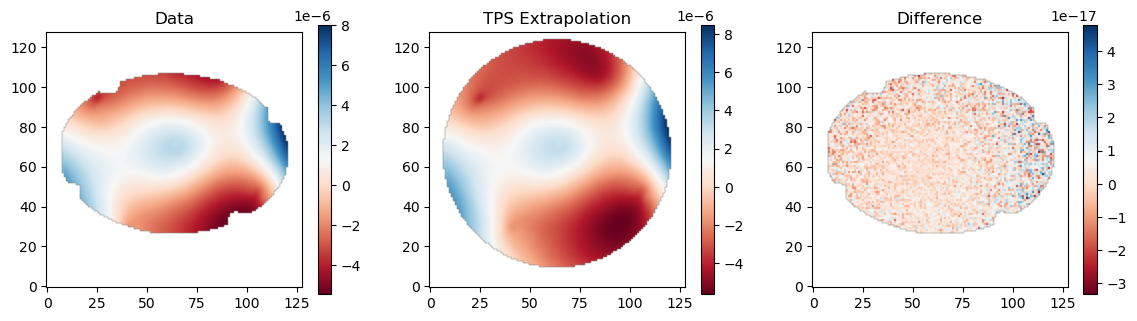

In [28]:
# extrapolate from img
cx,cy = get_photocenter(mask)
ext_mask = get_circular_mask(mask.shape,mask_radius=1080//2,mask_center=(cx,cy))

# Extrapolate missing data in image using thin-plate-spline interpolation
binned_shape = (128,128)
img_rebin = toccd(img,binned_shape)
mask_rebin = toccd(1-mask,binned_shape)
ext_mask_rebin = toccd(ext_mask,binned_shape)

# Keep same RMS on the rebinend image:
img_rebin *= xp.std(img[mask.astype(bool)])/xp.std(img_rebin[mask_rebin.astype(bool)])

# Extract valid (non-masked) pixel coordinates and values
valid_mask = ~mask_rebin.astype(bool)
y_valid, x_valid = xp.where(valid_mask)
z_valid = img_rebin[valid_mask]

# Create RBF interpolator with thin-plate spline
rbf = Rbf(xp.asnumpy(x_valid), xp.asnumpy(y_valid), xp.asnumpy(z_valid), function='thin_plate', smooth=0)

# Evaluate RBF on full grid to fill holes
Y, X = xp.mgrid[0:img_rebin.shape[0], 0:img_rebin.shape[1]]
diff_fill = xp.array(rbf(xp.asnumpy(X), xp.asnumpy(Y)))


plt.figure(figsize=(14, 3.5))
plt.subplot(1, 3, 1)
plt.imshow(masked_array(xp.asnumpy(img_rebin), mask=xp.asnumpy(mask_rebin)), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('Data')
plt.subplot(1, 3, 2)
plt.imshow(masked_array(xp.asnumpy(diff_fill), mask=xp.asnumpy(ext_mask_rebin)), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('TPS Extrapolation')
plt.subplot(1, 3, 3)
plt.imshow(masked_array(xp.asnumpy(diff_fill-img_rebin), mask=xp.asnumpy(mask_rebin)), origin='lower', cmap='RdBu')
plt.colorbar()
plt.title('Difference')

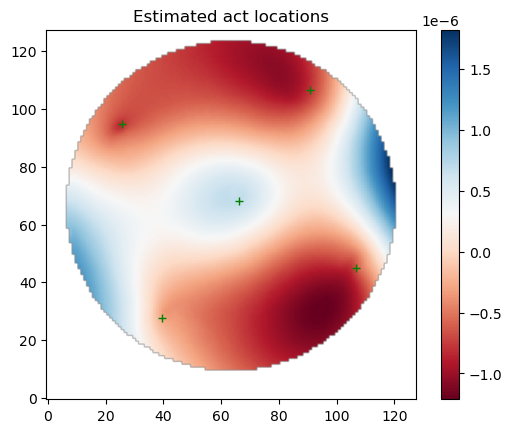

In [29]:
rebin_act_coords = act_coords/1200*128

rebin_frame = diff_fill.copy()
rebin_frame *= xp.std(img[mask.astype(bool)])/xp.std(rebin_frame[~mask_rebin.astype(bool)])

plt.figure()
plt.plot(xp.asnumpy(rebin_act_coords[1]),xp.asnumpy(rebin_act_coords[0]),'+',c='green')
plt.imshow(masked_array(xp.asnumpy(rebin_frame),mask=xp.asnumpy(ext_mask_rebin)),origin='lower',cmap='RdBu')
plt.title(f'Estimated act locations')
plt.colorbar()

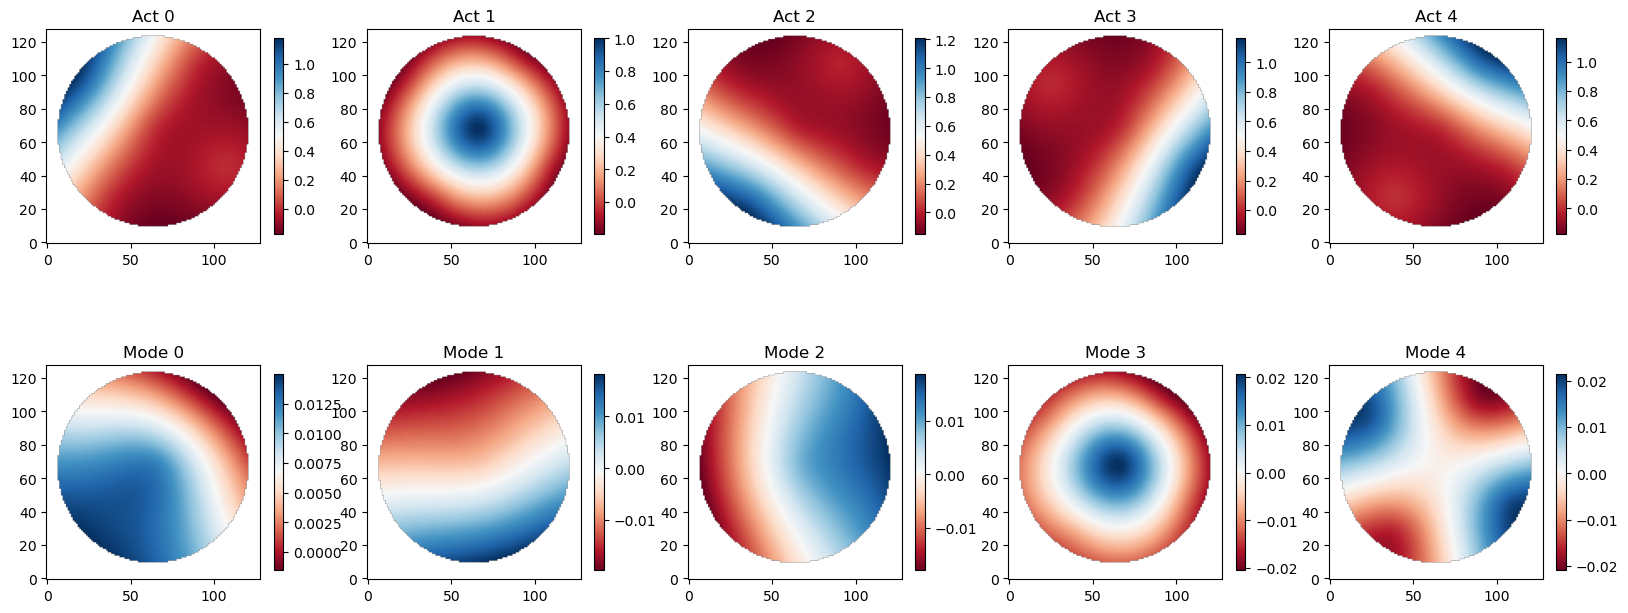

In [30]:
local_mask = xp.array((ext_mask_rebin).astype(bool))
rebinIF = simulate_influence_functions(act_coords=rebin_act_coords,local_mask=local_mask)
rebinR = xp.linalg.pinv(rebinIF)

U,_,_ = xp.linalg.svd(rebinIF,full_matrices=False)

plt.figure(figsize=(20,8))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(masked_array(xp.asnumpy(reshape_on_mask(rebinIF[:,i],local_mask)),mask=xp.asnumpy(local_mask)),origin='lower',cmap='RdBu')
    plt.colorbar(shrink=0.7)
    plt.title(f'Act {i}')
    plt.subplot(2,5,i+6)
    plt.imshow(masked_array(xp.asnumpy(reshape_on_mask(U[:,i],local_mask)),mask=xp.asnumpy(local_mask)),origin='lower',cmap='RdBu')
    plt.colorbar(shrink=0.7)
    plt.title(f'Mode {i}')

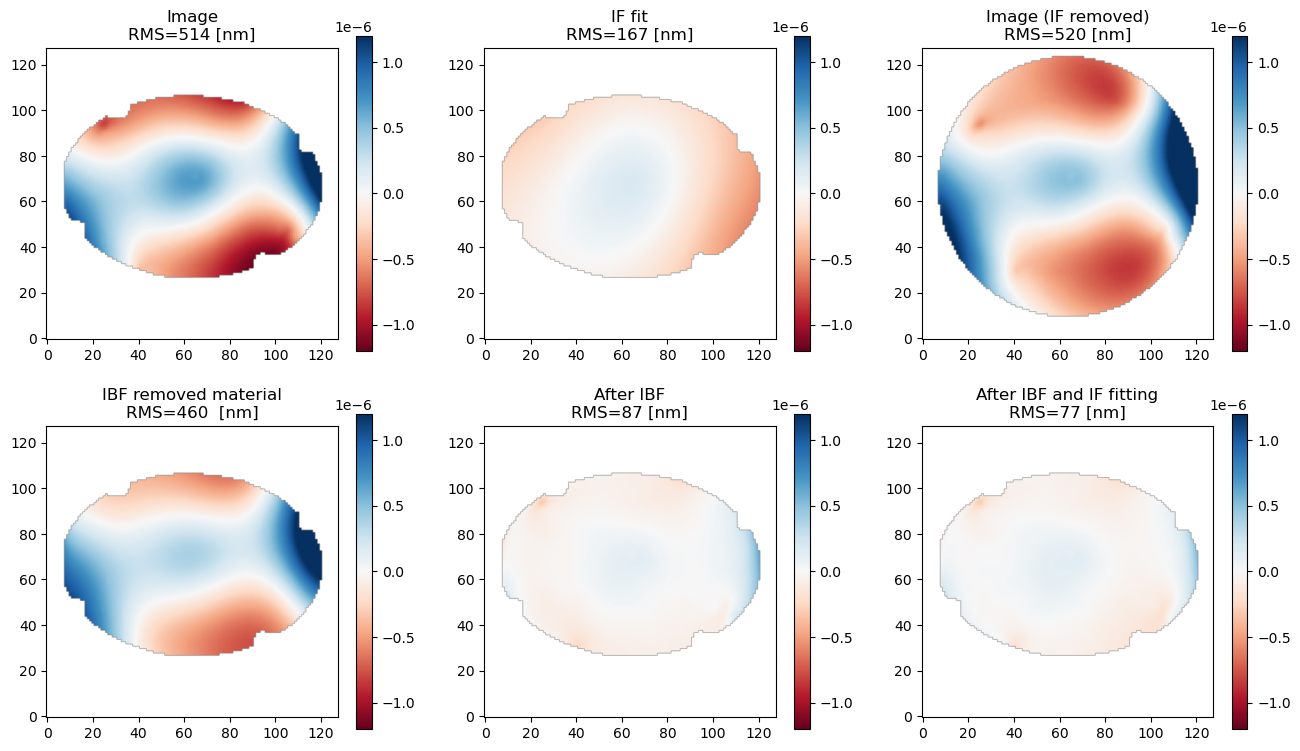

In [31]:
rebin_pix_scale = 100e-3/1100 / (128/1200)
ibf_img = simulate_ibf(rebin_frame, IF=rebinIF, R=rebinR, 
                       iff_mask=ext_mask_rebin.astype(bool),
                       mask = mask_rebin.astype(bool), 
                       fwhm=13e-3, amp=1e-8, pix_scale=rebin_pix_scale)

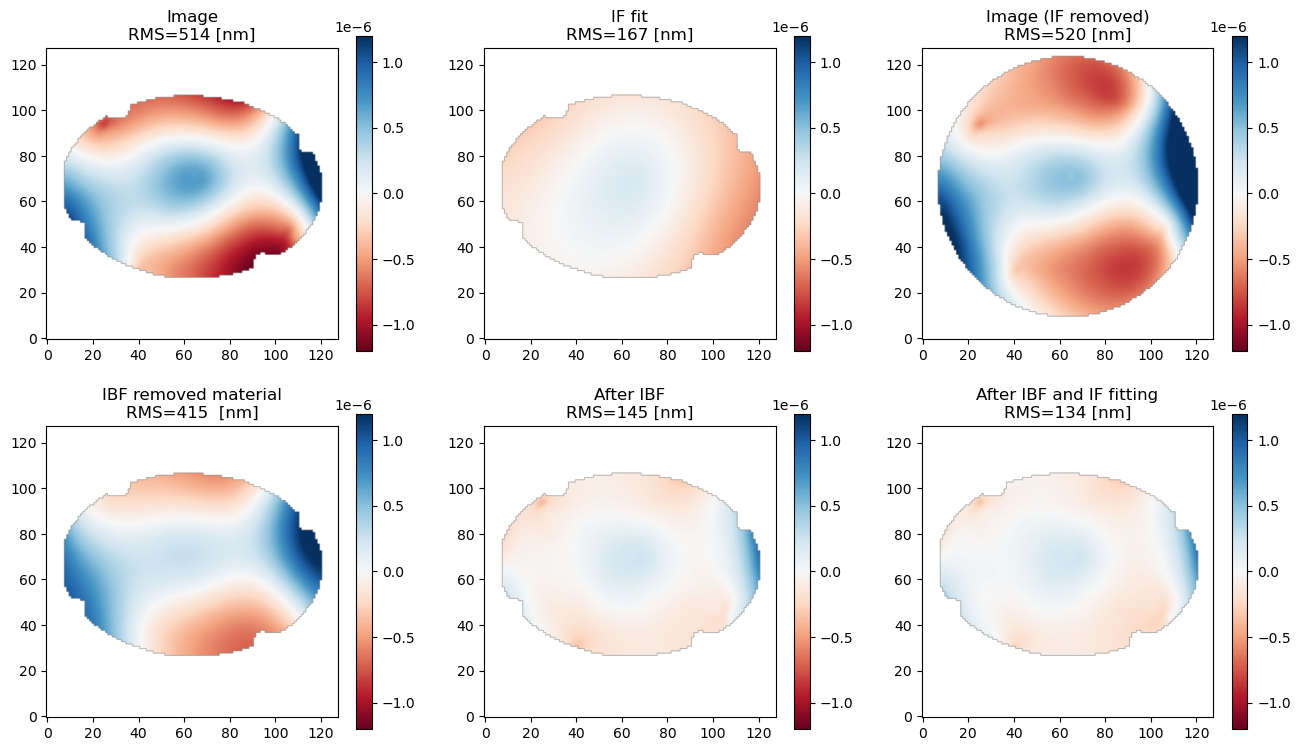

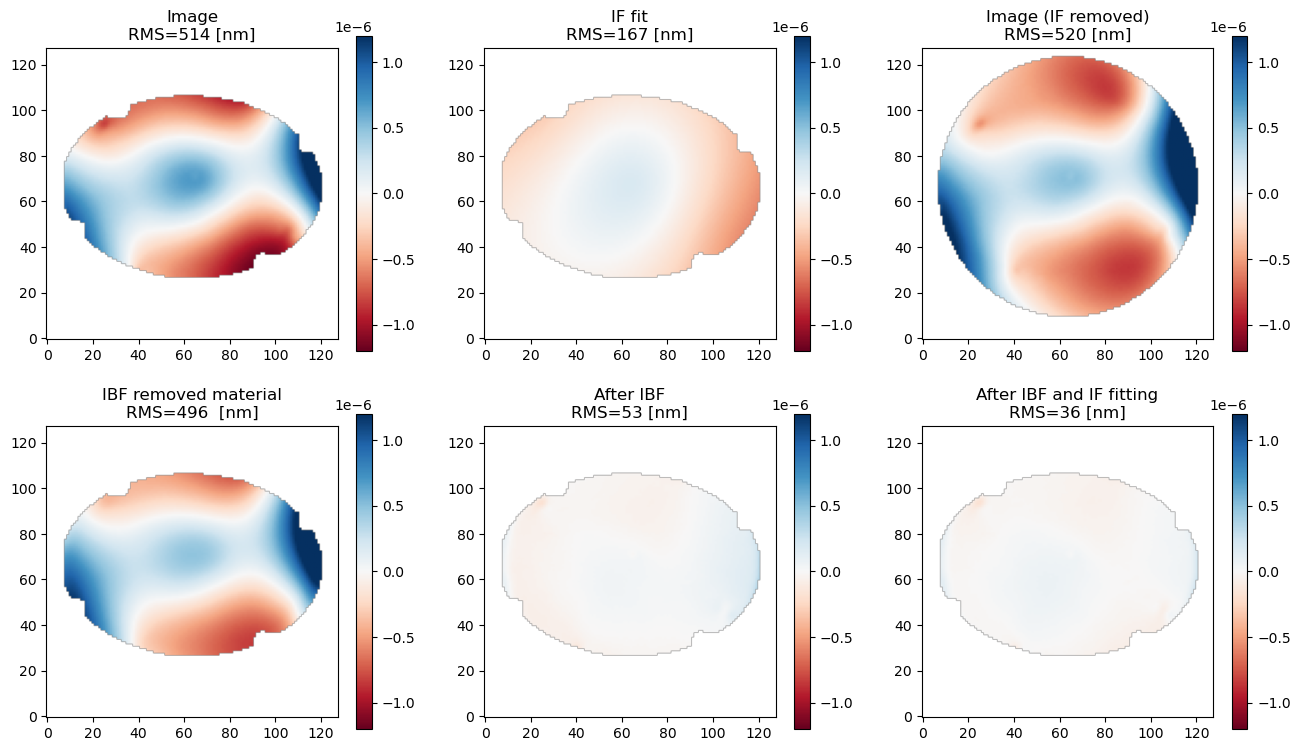

In [32]:
ibf_img = simulate_ibf(rebin_frame, IF=rebinIF, R=rebinR, 
                       iff_mask=ext_mask_rebin.astype(bool),
                       mask = mask_rebin.astype(bool), 
                       fwhm=20e-3, amp=1e-8, pix_scale=rebin_pix_scale)
ibf_img = simulate_ibf(rebin_frame, IF=rebinIF, R=rebinR, 
                       iff_mask=ext_mask_rebin.astype(bool),
                       mask = mask_rebin.astype(bool), 
                       fwhm=5e-3, amp=1e-8, pix_scale=rebin_pix_scale)